In [15]:
import sys
import torch
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Torch:", torch.__version__)

Python: 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]
Torch: 2.8.0


In [16]:
import os

print(os.getcwd())
print(os.listdir("."))

/Users/saral/Downloads/cyper/federated_heart_project
['Cardic disease complete code and data.zip', '.DS_Store', 'config.py', 'federated_multitask_train.py', 'train_feature_classifiers.py', 'ACDC_extracted', 'Cardic disease complete code and data', 'ACDC_extracted.zip', 'multitask_model.py', 'dataset.py', 'analyze_mri_features.py', 'extract_mri_features.py', 'deeplab_model.py', 'build_pathology_map.py', 'federated_seg_train.py', 'fl_outputs']


In [17]:
import os

for root, dirs, files in os.walk("ACDC_extracted"):
    level = root.replace("ACDC_extracted", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = "  " * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")
    
    if level >= 2:
        dirs[:] = []

ACDC_extracted/
  .DS_Store
  Cardic disease complete code and data/
    .DS_Store
    Cardiac_Disease.ipynb
    ACDC Dataset.zip
    result graphs.xlsx
    ACDC_preprocessed/
      .DS_Store


In [18]:
import os

base_path = "ACDC_extracted/Cardic disease complete code and data/ACDC_preprocessed"

print("Exists:", os.path.exists(base_path))
print("Contents:")
print(os.listdir(base_path)[:20])

Exists: True
Contents:
['.DS_Store', 'ACDC_training_volumes', 'ACDC_testing_volumes', 'ACDC_training_slices']


In [19]:
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = "  " * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")
    
    if level >= 2:
        dirs[:] = []

ACDC_preprocessed/
  .DS_Store
  ACDC_training_volumes/
    patient088_frame01.h5
    patient077_frame01.h5
    patient016_frame12.h5
    patient004_frame15.h5
    patient040_frame01.h5
    patient015_frame01.h5
    patient022_frame01.h5
    patient074_frame12.h5
    patient022_frame11.h5
    patient094_frame01.h5
  ACDC_testing_volumes/
    patient118_frame10.h5
    patient101_frame01.h5
    patient136_frame01.h5
    patient119_frame09.h5
    patient148_frame01.h5
    patient133_frame10.h5
    patient108_frame09.h5
    patient110_frame11.h5
    patient127_frame01.h5
    patient110_frame01.h5
  ACDC_training_slices/
    patient014_frame13_slice_3.h5
    patient014_frame01_slice_4.h5
    patient064_frame01_slice_5.h5
    patient020_frame11_slice_4.h5
    patient077_frame09_slice_1.h5
    patient012_frame13_slice_8.h5
    patient078_frame09_slice_3.h5
    patient013_frame14_slice_0.h5
    patient007_frame01_slice_5.h5
    patient077_frame01_slice_4.h5


In [20]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

slices_path = "ACDC_extracted/Cardic disease complete code and data/ACDC_preprocessed/ACDC_training_slices"

files = [f for f in os.listdir(slices_path) if f.endswith(".h5")]
print("Number of slice files:", len(files))
print("First file:", files[0])

sample_path = os.path.join(slices_path, files[0])

with h5py.File(sample_path, "r") as h5:
    print("Keys:", list(h5.keys()))
    for key in h5.keys():
        print(key, h5[key].shape, h5[key].dtype)

Number of slice files: 1912
First file: patient014_frame13_slice_3.h5
Keys: ['image', 'label', 'scribble']
image (216, 256) float32
label (216, 256) uint8
scribble (216, 256) uint16


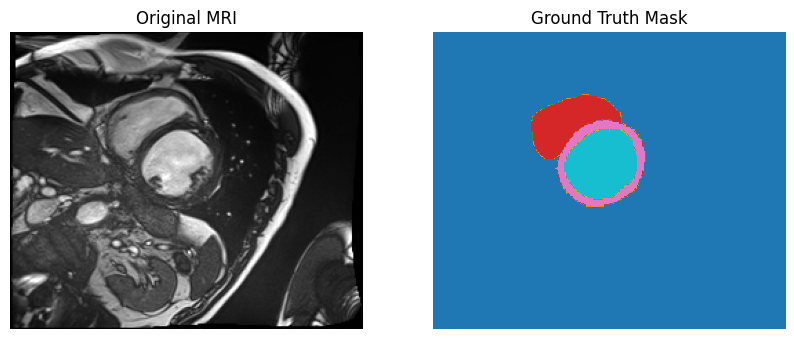

In [21]:
with h5py.File(sample_path, "r") as h5:
    image = h5["image"][:]
    mask = h5["label"][:]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="tab10")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

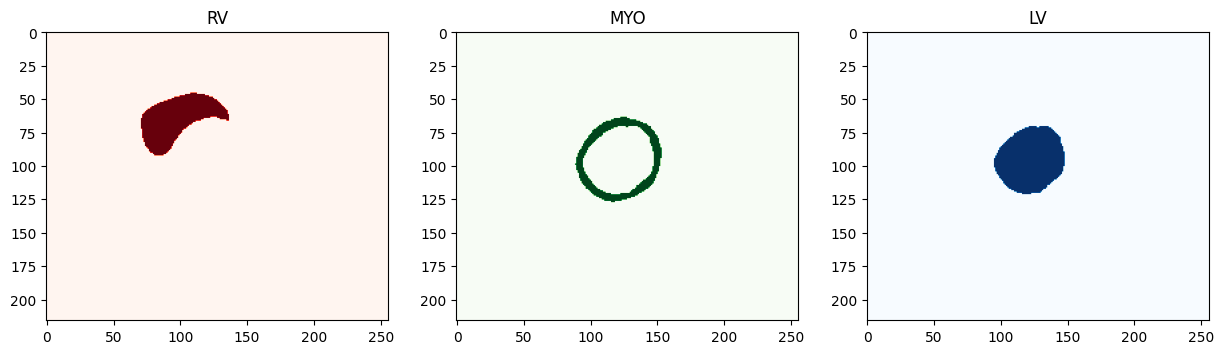

In [22]:
import numpy as np
import matplotlib.pyplot as plt

rv = (mask == 1)
myo = (mask == 2)
lv = (mask == 3)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rv, cmap="Reds")
plt.title("RV")

plt.subplot(1,3,2)
plt.imshow(myo, cmap="Greens")
plt.title("MYO")

plt.subplot(1,3,3)
plt.imshow(lv, cmap="Blues")
plt.title("LV")

plt.show()

In [23]:
import cv2
import numpy as np
import pandas as pd

def safe_circularity(area, perimeter):
    if perimeter == 0:
        return 0
    return (4 * np.pi * area) / (perimeter ** 2)

def structure_features(mask_binary, prefix):
    mask_binary = mask_binary.astype(np.uint8)
    area = int(np.sum(mask_binary > 0))

    contours, _ = cv2.findContours(
        mask_binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return {
            f"{prefix}_area": 0,
            f"{prefix}_perimeter": 0,
            f"{prefix}_circularity": 0,
            f"{prefix}_bbox_width": 0,
            f"{prefix}_bbox_height": 0,
            f"{prefix}_aspect_ratio": 0
        }

    contour = max(contours, key=cv2.contourArea)
    perimeter = float(cv2.arcLength(contour, True))
    x, y, w, h = cv2.boundingRect(contour)

    return {
        f"{prefix}_area": area,
        f"{prefix}_perimeter": perimeter,
        f"{prefix}_circularity": safe_circularity(area, perimeter),
        f"{prefix}_bbox_width": int(w),
        f"{prefix}_bbox_height": int(h),
        f"{prefix}_aspect_ratio": float(w / h) if h != 0 else 0
    }

def estimate_myo_thickness(myo_mask):
    """
    Thickness proxy:
    متوسط المسافة داخل عضلة القلب باستخدام distance transform.
    ليس قياس mm مباشر، لكنه مؤشر هندسي قريب من wall thickness.
    """
    myo_mask = myo_mask.astype(np.uint8)
    if np.sum(myo_mask) == 0:
        return 0

    dist = cv2.distanceTransform(myo_mask, cv2.DIST_L2, 5)
    return float(np.mean(dist[myo_mask > 0]))

def extract_scientific_cardiac_features(image, mask):
    """
    ACDC labels:
    0 = Background
    1 = RV
    2 = MYO
    3 = LV
    """

    rv_mask = (mask == 1).astype(np.uint8)
    myo_mask = (mask == 2).astype(np.uint8)
    lv_mask = (mask == 3).astype(np.uint8)

    features = {}

    features.update(structure_features(rv_mask, "rv"))
    features.update(structure_features(myo_mask, "myo"))
    features.update(structure_features(lv_mask, "lv"))

    features["myo_thickness_proxy"] = estimate_myo_thickness(myo_mask)

    features["lv_rv_area_ratio"] = (
        features["lv_area"] / features["rv_area"]
        if features["rv_area"] > 0 else 0
    )

    features["myo_lv_area_ratio"] = (
        features["myo_area"] / features["lv_area"]
        if features["lv_area"] > 0 else 0
    )

    return features

In [24]:
features = extract_scientific_cardiac_features(image, mask)

pd.DataFrame([features])

,rv_area,rv_perimeter,rv_circularity,rv_bbox_width,rv_bbox_height,rv_aspect_ratio,myo_area,myo_perimeter,myo_circularity,myo_bbox_width,myo_bbox_height,myo_aspect_ratio,lv_area,lv_perimeter,lv_circularity,lv_bbox_width,lv_bbox_height,lv_aspect_ratio,myo_thickness_proxy,lv_rv_area_ratio,myo_lv_area_ratio
0,1630,188.752307,0.574927,66,47,1.404255,1039,209.480228,0.297536,65,64,1.015625,2052,169.095453,0.901827,53,51,1.039216,1.870786,1.258896,0.506335


In [25]:
pd.set_option("display.max_columns", None)

pd.DataFrame([features])

,rv_area,rv_perimeter,rv_circularity,rv_bbox_width,rv_bbox_height,rv_aspect_ratio,myo_area,myo_perimeter,myo_circularity,myo_bbox_width,myo_bbox_height,myo_aspect_ratio,lv_area,lv_perimeter,lv_circularity,lv_bbox_width,lv_bbox_height,lv_aspect_ratio,myo_thickness_proxy,lv_rv_area_ratio,myo_lv_area_ratio
0,1630,188.752307,0.574927,66,47,1.404255,1039,209.480228,0.297536,65,64,1.015625,2052,169.095453,0.901827,53,51,1.039216,1.870786,1.258896,0.506335


In [26]:
import os
from collections import defaultdict

slices_path = "ACDC_extracted/Cardic disease complete code and data/ACDC_preprocessed/ACDC_training_slices"

patient_slices = defaultdict(list)

for f in os.listdir(slices_path):
    if f.endswith(".h5"):
        patient_id = f.split("_")[0]
        patient_slices[patient_id].append(f)

print("Number of patients:", len(patient_slices))

for pid in list(patient_slices.keys())[:10]:
    print(pid, len(patient_slices[pid]))

Number of patients: 100
patient014 20
patient064 20
patient020 16
patient077 16
patient012 20
patient078 16
patient013 20
patient007 20
patient001 30
patient008 20


In [29]:
import os
import h5py
import cv2
import numpy as np
import pandas as pd
from collections import defaultdict

In [30]:
def extract_patient_features(mask):

    rv = (mask == 1).astype(np.uint8)
    myo = (mask == 2).astype(np.uint8)
    lv = (mask == 3).astype(np.uint8)

    return {
        "rv_area": np.sum(rv),
        "myo_area": np.sum(myo),
        "lv_area": np.sum(lv)
    }

In [31]:
slices_path = "ACDC_extracted/Cardic disease complete code and data/ACDC_preprocessed/ACDC_training_slices"

patients = defaultdict(list)

for fname in os.listdir(slices_path):

    if not fname.endswith(".h5"):
        continue

    patient_id = fname.split("_")[0]

    with h5py.File(os.path.join(slices_path, fname), "r") as h5:

        mask = h5["label"][:]

        features = extract_patient_features(mask)

        patients[patient_id].append(features)

rows = []

for patient_id, slices in patients.items():

    rv_volume = sum(x["rv_area"] for x in slices)
    myo_volume = sum(x["myo_area"] for x in slices)
    lv_volume = sum(x["lv_area"] for x in slices)

    rows.append({
        "patient_id": patient_id,
        "rv_volume_proxy": rv_volume,
        "myo_volume_proxy": myo_volume,
        "lv_volume_proxy": lv_volume,
        "lv_rv_ratio": lv_volume / rv_volume if rv_volume > 0 else 0,
        "myo_lv_ratio": myo_volume / lv_volume if lv_volume > 0 else 0
    })

patient_df = pd.DataFrame(rows)

print(patient_df.shape)

patient_df.head()

(100, 6)


,patient_id,rv_volume_proxy,myo_volume_proxy,lv_volume_proxy,lv_rv_ratio,myo_lv_ratio
0,patient014,22568,17421,33213,1.471686,0.524524
1,patient064,13451,13921,9372,0.696751,1.485382
2,patient020,10721,8170,13230,1.234027,0.617536
3,patient077,12008,9651,9063,0.754747,1.064879
4,patient012,6202,12355,22199,3.579329,0.556557


In [32]:
def get_disease_label_from_patient(patient_id):
    """
    ACDC training set:
    patient001 - patient020 = NOR
    patient021 - patient040 = DCM
    patient041 - patient060 = HCM
    patient061 - patient080 = MINF
    patient081 - patient100 = ARV/RV
    """
    num = int(patient_id.replace("patient", ""))

    if num <= 20:
        return "NOR", 0
    elif num <= 40:
        return "DCM", 1
    elif num <= 60:
        return "HCM", 2
    elif num <= 80:
        return "MINF", 3
    else:
        return "ARV", 4

In [33]:
patients = defaultdict(list)

for fname in os.listdir(slices_path):

    if not fname.endswith(".h5"):
        continue

    patient_id = fname.split("_")[0]

    with h5py.File(os.path.join(slices_path, fname), "r") as h5:
        image = h5["image"][:]
        mask = h5["label"][:]

        slice_features = extract_scientific_cardiac_features(image, mask)
        patients[patient_id].append(slice_features)

rows = []

for patient_id, slices in patients.items():

    disease_label, disease_label_id = get_disease_label_from_patient(patient_id)

    rv_areas = [s["rv_area"] for s in slices]
    myo_areas = [s["myo_area"] for s in slices]
    lv_areas = [s["lv_area"] for s in slices]

    rv_circularities = [s["rv_circularity"] for s in slices]
    myo_circularities = [s["myo_circularity"] for s in slices]
    lv_circularities = [s["lv_circularity"] for s in slices]

    thicknesses = [s["myo_thickness_proxy"] for s in slices]

    rv_volume = sum(rv_areas)
    myo_volume = sum(myo_areas)
    lv_volume = sum(lv_areas)

    rows.append({
        "patient_id": patient_id,
        "disease_label": disease_label,
        "disease_label_id": disease_label_id,
        "num_slices": len(slices),

        "rv_volume_proxy": rv_volume,
        "myo_volume_proxy": myo_volume,
        "lv_volume_proxy": lv_volume,

        "rv_area_mean": np.mean(rv_areas),
        "rv_area_max": np.max(rv_areas),

        "myo_area_mean": np.mean(myo_areas),
        "myo_area_max": np.max(myo_areas),

        "lv_area_mean": np.mean(lv_areas),
        "lv_area_max": np.max(lv_areas),

        "rv_circularity_mean": np.mean(rv_circularities),
        "myo_circularity_mean": np.mean(myo_circularities),
        "lv_circularity_mean": np.mean(lv_circularities),

        "myo_thickness_mean": np.mean(thicknesses),
        "myo_thickness_max": np.max(thicknesses),

        "lv_rv_ratio": lv_volume / rv_volume if rv_volume > 0 else 0,
        "myo_lv_ratio": myo_volume / lv_volume if lv_volume > 0 else 0,
        "myo_rv_ratio": myo_volume / rv_volume if rv_volume > 0 else 0
    })

patient_features_df = pd.DataFrame(rows)

patient_features_df = patient_features_df.sort_values("patient_id").reset_index(drop=True)

print(patient_features_df.shape)
patient_features_df.head()

(100, 21)


,patient_id,disease_label,disease_label_id,num_slices,rv_volume_proxy,myo_volume_proxy,lv_volume_proxy,rv_area_mean,rv_area_max,myo_area_mean,myo_area_max,lv_area_mean,lv_area_max,rv_circularity_mean,myo_circularity_mean,lv_circularity_mean,myo_thickness_mean,myo_thickness_max,lv_rv_ratio,myo_lv_ratio,myo_rv_ratio
0,patient001,NOR,0,30,12430,21366,32993,414.333333,1455,712.20,1106,1099.766667,1765,0.364504,0.335646,0.826033,1.675010,2.234512,2.654304,0.647592,1.718906
1,patient002,NOR,0,20,6594,18885,24291,329.700000,1493,944.25,1574,1214.550000,2102,0.405817,0.434117,0.920750,2.150070,2.855569,3.683803,0.777448,2.863967
2,patient003,NOR,0,20,15029,16094,21209,751.450000,1549,804.70,1025,1060.450000,1589,0.417584,0.423802,0.909735,1.990623,2.191002,1.411205,0.758829,1.070863
3,patient004,NOR,0,20,10208,18372,26071,510.400000,1489,918.60,1298,1303.550000,1914,0.305527,0.406028,0.920760,2.027235,2.327592,2.553977,0.704691,1.799765
4,patient005,NOR,0,20,12390,21929,26037,619.500000,1700,1096.45,1589,1301.850000,2127,0.362242,0.429630,0.895217,2.239727,2.822016,2.101453,0.842225,1.769895


In [34]:
os.makedirs("fl_outputs", exist_ok=True)

output_path = "fl_outputs/patient_level_scientific_cardiac_features.csv"

patient_features_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: fl_outputs/patient_level_scientific_cardiac_features.csv


In [35]:
patient_features_df.head()
patient_features_df["disease_label"].value_counts()

disease_label
NOR     20
DCM     20
HCM     20
MINF    20
ARV     20
Name: count, dtype: int64

In [37]:
patient_features_df.groupby("disease_label")[
[
    "rv_volume_proxy",
    "myo_volume_proxy",
    "lv_volume_proxy",
    "myo_thickness_mean",
    "lv_rv_ratio"
]
].mean().round(2)

,rv_volume_proxy,myo_volume_proxy,lv_volume_proxy,myo_thickness_mean,lv_rv_ratio
disease_label,,,,,
ARV,20732.20,9881.9,9931.2,1.70,0.48
DCM,8417.70,18184.8,8939.0,2.77,1.05
HCM,9217.85,13321.1,14586.1,2.02,1.89
MINF,10277.85,9883.8,8418.7,1.93,0.83
NOR,13370.35,15478.0,23637.2,1.85,1.97


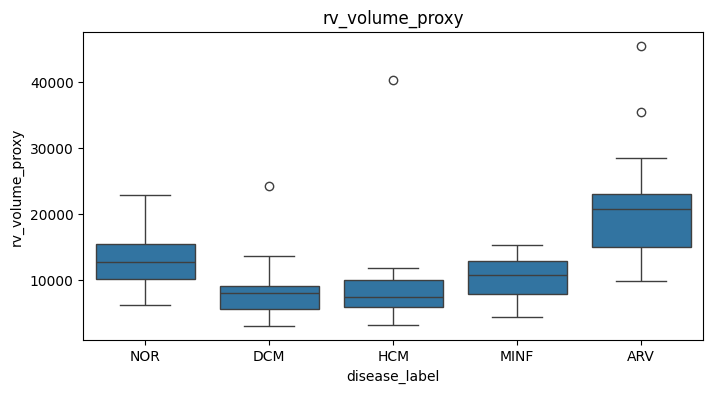

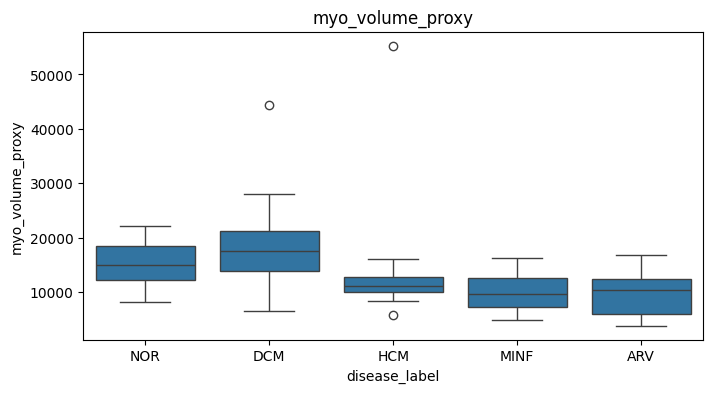

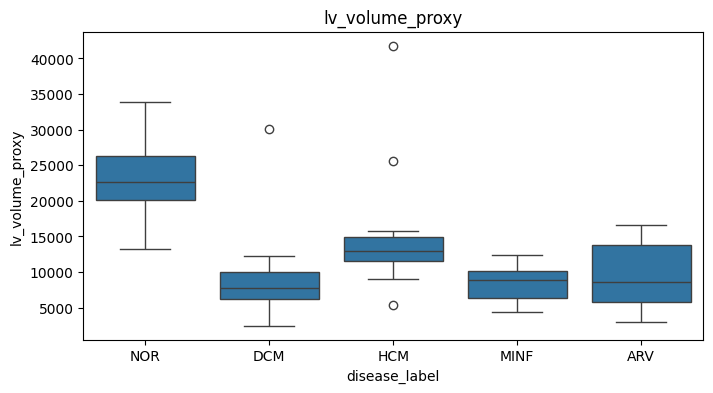

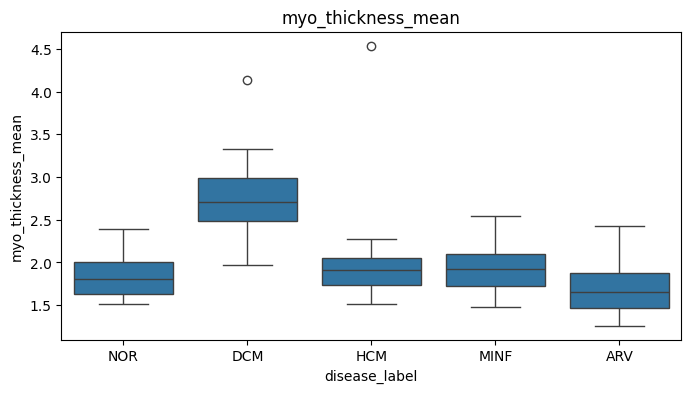

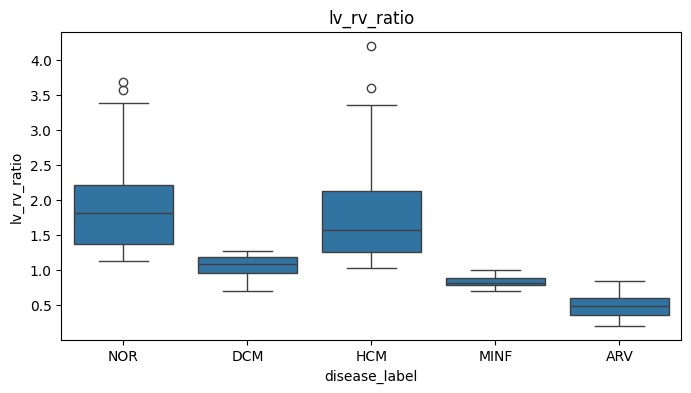

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = [
    "rv_volume_proxy",
    "myo_volume_proxy",
    "lv_volume_proxy",
    "myo_thickness_mean",
    "lv_rv_ratio"
]

for feat in features_to_plot:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=patient_features_df,
        x="disease_label",
        y=feat
    )

    plt.title(feat)
    plt.show()

In [40]:
print(confusion_matrix(y_test, preds))

[[3 0 1 0 0]
 [0 4 0 0 0]
 [0 0 4 0 0]
 [0 0 0 4 0]
 [0 0 0 0 4]]


In [41]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

cm = confusion_matrix(y_test, preds)

class_names = ["NOR", "DCM", "HCM", "MINF", "ARV"]

print("\nDetailed Medical Metrics")
print("="*60)

sensitivities = []
specificities = []

for i, cls in enumerate(class_names):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0

    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

    print(f"{cls}")
    print(f"  Sensitivity : {sensitivity:.4f}")
    print(f"  Specificity : {specificity:.4f}")
    print()

avg_sensitivity = np.mean(sensitivities)
avg_specificity = np.mean(specificities)

precision = precision_score(
    y_test,
    preds,
    average="weighted"
)

recall = recall_score(
    y_test,
    preds,
    average="weighted"
)

f1 = f1_score(
    y_test,
    preds,
    average="weighted"
)

print("="*60)
print("Overall Performance")
print("="*60)

print(f"Accuracy     : {acc:.4f}")
print(f"Sensitivity  : {avg_sensitivity:.4f}")
print(f"Specificity  : {avg_specificity:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")


Detailed Medical Metrics
NOR
  Sensitivity : 0.7500
  Specificity : 1.0000

DCM
  Sensitivity : 1.0000
  Specificity : 1.0000

HCM
  Sensitivity : 1.0000
  Specificity : 0.9375

MINF
  Sensitivity : 1.0000
  Specificity : 1.0000

ARV
  Sensitivity : 1.0000
  Specificity : 1.0000

Overall Performance
Accuracy     : 0.9500
Sensitivity  : 0.9500
Specificity  : 0.9875
Precision    : 0.9600
Recall       : 0.9500
F1-score     : 0.9492


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

feature_cols = [
    "num_slices",
    "rv_volume_proxy",
    "myo_volume_proxy",
    "lv_volume_proxy",
    "rv_area_mean",
    "rv_area_max",
    "myo_area_mean",
    "myo_area_max",
    "lv_area_mean",
    "lv_area_max",
    "rv_circularity_mean",
    "myo_circularity_mean",
    "lv_circularity_mean",
    "myo_thickness_mean",
    "myo_thickness_max",
    "lv_rv_ratio",
    "myo_lv_ratio",
    "myo_rv_ratio"
]

X = patient_features_df[feature_cols].fillna(0)
y = patient_features_df["disease_label_id"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    objective="multi:softmax",
    num_class=5,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

preds = xgb_model.predict(X_test_scaled)

acc = accuracy_score(y_test, preds)

print("XGBoost Accuracy:", acc)
print()
print(classification_report(
    y_test,
    preds,
    target_names=["NOR", "DCM", "HCM", "MINF", "ARV"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

XGBoost Accuracy: 0.95

              precision    recall  f1-score   support

         NOR       1.00      0.75      0.86         4
         DCM       1.00      1.00      1.00         4
         HCM       0.80      1.00      0.89         4
        MINF       1.00      1.00      1.00         4
         ARV       1.00      1.00      1.00         4

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20

Confusion Matrix:
[[3 0 1 0 0]
 [0 4 0 0 0]
 [0 0 4 0 0]
 [0 0 0 4 0]
 [0 0 0 0 4]]


In [43]:
feature_cols = [
    "num_slices",
    "rv_volume_proxy",
    "myo_volume_proxy",
    "lv_volume_proxy",
    "rv_area_mean",
    "rv_area_max",
    "myo_area_mean",
    "myo_area_max",
    "lv_area_mean",
    "lv_area_max",
    "rv_circularity_mean",
    "myo_circularity_mean",
    "lv_circularity_mean",
    "myo_thickness_mean",
    "myo_thickness_max",
    "lv_rv_ratio",
    "myo_lv_ratio",
    "myo_rv_ratio"
]

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_acc)

print(classification_report(
    y_test,
    rf_preds,
    target_names=["NOR","DCM","HCM","MINF","ARV"]
))

print(confusion_matrix(y_test, rf_preds))

Random Forest Accuracy: 0.95
              precision    recall  f1-score   support

         NOR       0.80      1.00      0.89         4
         DCM       1.00      0.75      0.86         4
         HCM       1.00      1.00      1.00         4
        MINF       1.00      1.00      1.00         4
         ARV       1.00      1.00      1.00         4

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20

[[4 0 0 0 0]
 [1 3 0 0 0]
 [0 0 4 0 0]
 [0 0 0 4 0]
 [0 0 0 0 4]]


In [45]:
!pip install pytorch-tabnet

zsh:1: command not found: pip


In [46]:
from pytorch_tabnet.tab_model import TabNetClassifier

print("TabNet imported successfully")

TabNet imported successfully


In [51]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

tabnet = TabNetClassifier(
    n_d=8,
    n_a=8,
    n_steps=3,
    gamma=1.3,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-2),
    seed=42,
    verbose=1
)

tabnet.fit(
    X_train_scaled.astype("float32"),
    y_train.values,
    eval_set=[(X_test_scaled.astype("float32"), y_test.values)],
    eval_name=["test"],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=20,
    batch_size=16,
    virtual_batch_size=8
)

tab_preds = tabnet.predict(X_test_scaled.astype("float32"))

tab_acc = accuracy_score(y_test, tab_preds)

print("TabNet Accuracy:", tab_acc)
print()

print(classification_report(
    y_test,
    tab_preds,
    target_names=["NOR", "DCM", "HCM", "MINF", "ARV"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, tab_preds))

/Users/saral/Library/Python/3.9/lib/python/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.21797 | test_accuracy: 0.2     |  0:00:00s
epoch 1  | loss: 1.83832 | test_accuracy: 0.15    |  0:00:00s
epoch 2  | loss: 1.85342 | test_accuracy: 0.1     |  0:00:00s
epoch 3  | loss: 1.56599 | test_accuracy: 0.15    |  0:00:00s
epoch 4  | loss: 1.60187 | test_accuracy: 0.3     |  0:00:00s
epoch 5  | loss: 1.62052 | test_accuracy: 0.4     |  0:00:00s
epoch 6  | loss: 1.52517 | test_accuracy: 0.35    |  0:00:00s
epoch 7  | loss: 1.3758  | test_accuracy: 0.4     |  0:00:00s
epoch 8  | loss: 1.45857 | test_accuracy: 0.45    |  0:00:00s
epoch 9  | loss: 1.39362 | test_accuracy: 0.4     |  0:00:00s
epoch 10 | loss: 1.37626 | test_accuracy: 0.4     |  0:00:00s
epoch 11 | loss: 1.33415 | test_accuracy: 0.45    |  0:00:00s
epoch 12 | loss: 1.37809 | test_accuracy: 0.6     |  0:00:00s
epoch 13 | loss: 1.32159 | test_accuracy: 0.55    |  0:00:00s
epoch 14 | loss: 1.30123 | test_accuracy: 0.55    |  0:00:01s
epoch 15 | loss: 1.30882 | test_accuracy: 0.55    |  0:00:01s
epoch 16

/Users/saral/Library/Python/3.9/lib/python/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tab_preds = tabnet.predict(X_test_scaled.astype("float32"))

tab_acc = accuracy_score(y_test, tab_preds)

print("TabNet Final Accuracy:", tab_acc)
print()

print(classification_report(
    y_test,
    tab_preds,
    target_names=["NOR", "DCM", "HCM", "MINF", "ARV"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, tab_preds))

TabNet Final Accuracy: 0.85

              precision    recall  f1-score   support

         NOR       1.00      0.75      0.86         4
         DCM       1.00      0.75      0.86         4
         HCM       0.80      1.00      0.89         4
        MINF       0.80      1.00      0.89         4
         ARV       0.75      0.75      0.75         4

    accuracy                           0.85        20
   macro avg       0.87      0.85      0.85        20
weighted avg       0.87      0.85      0.85        20

Confusion Matrix:
[[3 0 1 0 0]
 [0 3 0 0 1]
 [0 0 4 0 0]
 [0 0 0 4 0]
 [0 0 0 1 3]]


In [53]:
cm = confusion_matrix(y_test, tab_preds)

class_names = ["NOR", "DCM", "HCM", "MINF", "ARV"]

sensitivities = []
specificities = []

for i, cls in enumerate(class_names):

    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

    print(f"{cls}: Sensitivity={sensitivity:.4f}, Specificity={specificity:.4f}")

print("\nOverall TabNet Performance")
print("="*50)
print(f"Accuracy     : {tab_acc:.4f}")
print(f"Sensitivity  : {np.mean(sensitivities):.4f}")
print(f"Specificity  : {np.mean(specificities):.4f}")
print(f"Precision    : {precision_score(y_test, tab_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall       : {recall_score(y_test, tab_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-score     : {f1_score(y_test, tab_preds, average='weighted', zero_division=0):.4f}")

NOR: Sensitivity=0.7500, Specificity=1.0000
DCM: Sensitivity=0.7500, Specificity=1.0000
HCM: Sensitivity=1.0000, Specificity=0.9375
MINF: Sensitivity=1.0000, Specificity=0.9375
ARV: Sensitivity=0.7500, Specificity=0.9375

Overall TabNet Performance
Accuracy     : 0.8500
Sensitivity  : 0.8500
Specificity  : 0.9625
Precision    : 0.8700
Recall       : 0.8500
F1-score     : 0.8484


In [ ]:
# ============================================================
# Stage 3: Integrated Multi-Source Cardiac Dataset Framework
# ============================================================

In [54]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".csv") or f.endswith(".data") or f.endswith(".zip"):
            print(os.path.join(root, f))

./Cardic disease complete code and data.zip
./ACDC_extracted.zip
./ACDC_extracted/Cardic disease complete code and data/ACDC Dataset.zip
./Cardic disease complete code and data/ACDC Dataset.zip
./fl_outputs/patient_level_scientific_cardiac_features.csv
./fl_outputs/mri_extracted_features.csv
./fl_outputs/results.csv


                 feature  importance
3        lv_volume_proxy    0.169418
16          myo_lv_ratio    0.146785
8           lv_area_mean    0.115397
15           lv_rv_ratio    0.099743
17          myo_rv_ratio    0.090822
0             num_slices    0.085944
11  myo_circularity_mean    0.076046
2       myo_volume_proxy    0.042703
1        rv_volume_proxy    0.033095
14     myo_thickness_max    0.027902


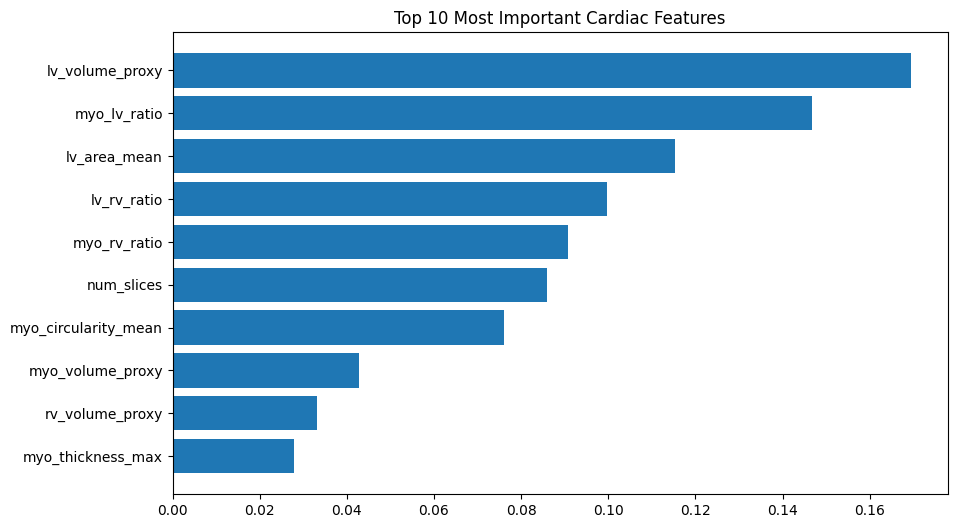

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    importance["feature"][:10],
    importance["importance"][:10]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Cardiac Features")
plt.show()